In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("Iris1.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [8]:
df.dropna(inplace=True)

In [9]:
df['species'].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


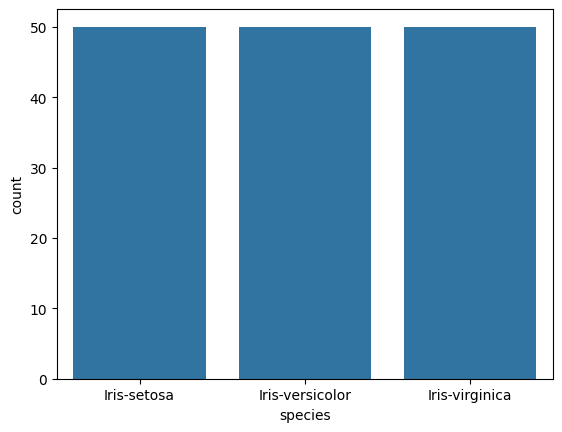

In [10]:
sns.countplot(x='species', data=df)

plt.show()

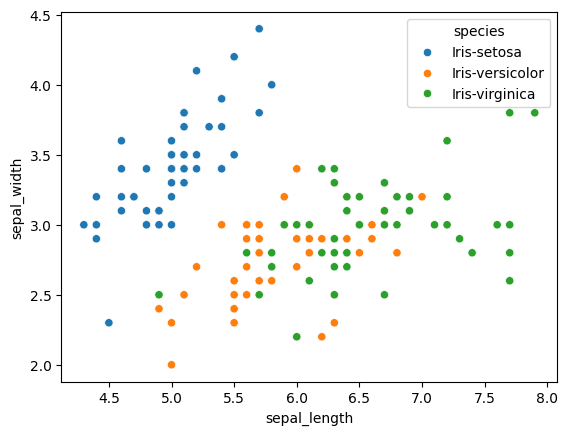

In [11]:
sns.scatterplot(
    x='sepal_length',
    y='sepal_width',
    hue='species',
    data=df
)

plt.show()

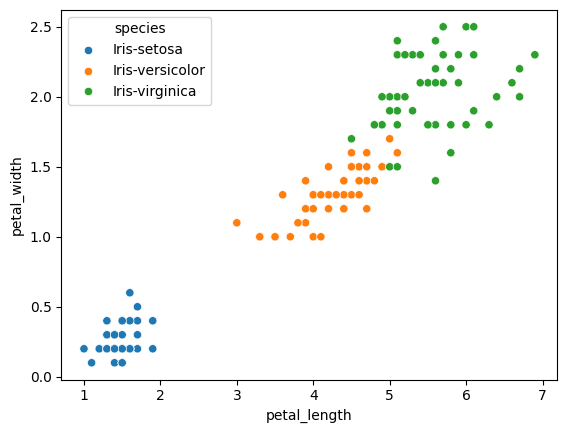

In [12]:
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df
)

plt.show()

In [13]:
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
X = df.drop('species', axis=1)
y = df['species']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
accuracy_score(y_test,lr_pred)

1.0

In [17]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

accuracy_score(y_test,dt_pred)

1.0

In [18]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

accuracy_score(y_test,knn_pred)

1.0

In [19]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

accuracy_score(y_test,rf_pred)

1.0

In [20]:
models = pd.DataFrame({

'Model':
[
'Logistic Regression',
'Decision Tree',
'KNN',
'Random Forest'
],

'Accuracy':
[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,knn_pred),
accuracy_score(y_test,rf_pred)

]

})


models

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,KNN,1.0
3,Random Forest,1.0


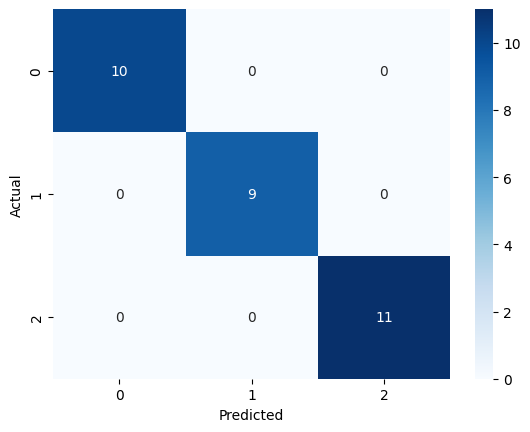

In [21]:
cm = confusion_matrix(y_test,rf_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [23]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [24]:
# Taking input from user

sepal_length = float(input("Enter sepal length: "))
sepal_width = float(input("Enter sepal width: "))
petal_length = float(input("Enter petal length: "))
petal_width = float(input("Enter petal width: "))


# Creating input array

flower = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]


# Prediction

prediction = rf.predict(flower)

flower_name = encoder.inverse_transform(prediction)


print("Predicted Flower Species:", flower_name[0])

Enter sepal length: 5.1
Enter sepal width: 2.3
Enter petal length: 4.6
Enter petal width: 5.1
Predicted Flower Species: Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
